In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import time
import os
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False 

# 设备配置
device = torch.device("cpu")  
BATCH_SIZE = 64
NUM_CLASSES = 10
CALIBRATION_BATCHES = 100  # 校准使用的批次数量

使用 scipy.io 加载 SVHN 数据集的 MATLAB 格式文件，分离出图像数据和对应的标签

In [3]:
# 加载原始数据
train_raw = sio.loadmat("./data/train_32x32.mat")
test_raw = sio.loadmat("./data/test_32x32.mat")

train_X = train_raw["X"]
train_y = train_raw["y"]
test_X = test_raw["X"]
test_y = test_raw["y"]

将原始数据集的 (高度，宽度，通道，样本数) 维度顺序，转换为 PyTorch 要求的 (样本数，通道，高度，宽度) 格式。

In [4]:
# 维度转换
train_X = np.transpose(train_X, (3, 2, 0, 1))
test_X = np.transpose(test_X, (3, 2, 0, 1))

将二维标签数组展平为一维，并将原始数据中代表数字 0 的标签 10 替换为 0，使标签范围符合 0-9 的分类要求。

In [5]:
# 标签处理
train_y = train_y.flatten()
test_y = test_y.flatten()
train_y[train_y == 10] = 0
test_y[test_y == 10] = 0

定义训练集和测试集的数据预处理流程，训练集使用多种数据增强手段防止过拟合，两者都使用 ImageNet 的均值和标准差进行归一化。

In [6]:
# 数据增强与归一化
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

自定义 PyTorch 数据集类封装 SVHN 数据，实现数据的索引访问功能，然后创建训练、测试和校准用的数据加载器，实现批次化数据加载。

In [7]:
# 数据集封装
class SVHNDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img = np.transpose(self.data[idx], (1, 2, 0))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_dataset = SVHNDataset(train_X, train_y, transform=train_transform)
test_dataset = SVHNDataset(test_X, test_y, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 校准集（从训练集中抽取）
calibration_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0
)

定义作业 2 中使用的三层卷积加两层全连接的 CNN 模型结构，包含批量归一化和 Dropout 正则化，并添加模块融合方法用于后续量化。

In [18]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # 卷积块:Conv + BN + ReLU + Pool + Dropout2d
        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.2)
        
        self.conv2 = nn.Conv2d(16, 32, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.3)
        
        self.conv3 = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout2d(0.3)
        
        # 全连接层
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.drop1(self.pool1(self.relu1(self.bn1(self.conv1(x)))))
        x = self.drop2(self.pool2(self.relu2(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(self.relu3(self.bn3(self.conv3(x)))))
        x = x.view(-1, 64 * 4 * 4)
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
    
    def fuse_model(self):
        """融合Conv+BN+ReLU和Linear+ReLU模块"""
        torch.ao.quantization.fuse_modules(self, [['conv1', 'bn1', 'relu1'],
                                                 ['conv2', 'bn2', 'relu2'],
                                                 ['conv3', 'bn3', 'relu3'],
                                                 ['fc1', 'relu4']], inplace=True)

手动实现 per-tensor 非对称线性量化和反量化的核心函数，计算缩放因子和零点，完成浮点张量与 INT8 整数张量之间的转换。

In [20]:
def linear_quantize(x, num_bits=8):
    """
    手动实现per-tensor非对称线性量化
    Args:
        x: 输入浮点张量
        num_bits: 量化位数，默认为8
    Returns:
        q: 量化后的整数张量
        scale: 量化缩放因子
        zero_point: 量化零点
    """
    q_min = 0
    q_max = 2 ** num_bits - 1
    
    # 计算张量的最小值和最大值
    x_min = torch.min(x).item()
    x_max = torch.max(x).item()
    
    # 计算缩放因子和零点
    scale = (x_max - x_min) / (q_max - q_min)
    zero_point = q_min - round(x_min / scale)
    
    # 限制零点在有效范围内
    zero_point = max(q_min, min(q_max, zero_point))
    
    # 执行量化
    q = torch.round(x / scale + zero_point)
    q = torch.clamp(q, q_min, q_max).to(torch.int8)
    
    return q, scale, zero_point

def linear_dequantize(q, scale, zero_point):
    """
    手动实现线性反量化
    Args:
        q: 量化后的整数张量
        scale: 量化缩放因子
        zero_point: 量化零点
    Returns:
        x: 反量化后的浮点张量
    """
    x = scale * (q.float() - zero_point)
    return x

在原始模型基础上添加量化和反量化节点，标记模型输入输出的量化边界，使用 reshape 代替 view 解决量化后张量不连续的问题，并保留模块融合功能。

In [21]:
class QuantizableSimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(QuantizableSimpleCNN, self).__init__()
        # 量化和反量化节点
        self.quant = torch.ao.quantization.QuantStub()
        self.dequant = torch.ao.quantization.DeQuantStub()
        
        # 卷积块
        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.2)
        
        self.conv2 = nn.Conv2d(16, 32, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.3)
        
        self.conv3 = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout2d(0.3)
        
        # 全连接层
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.quant(x)
        x = self.drop1(self.pool1(self.relu1(self.bn1(self.conv1(x)))))
        x = self.drop2(self.pool2(self.relu2(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(self.relu3(self.bn3(self.conv3(x)))))
        # 修复：使用reshape代替view，解决量化后张量不连续的问题
        x = x.reshape(-1, 64 * 4 * 4)
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dequant(x)
        return x
    
    def fuse_model(self):
        """融合Conv+BN+ReLU和Linear+ReLU模块"""
        torch.ao.quantization.fuse_modules(self, [['conv1', 'bn1', 'relu1'],
                                                 ['conv2', 'bn2', 'relu2'],
                                                 ['conv3', 'bn3', 'relu3'],
                                                 ['fc1', 'relu4']], inplace=True)

加载作业 2 中训练好的 FP32 模型权重，切换到评估模式，保存模型文件并计算其大小，作为后续量化对比的基线。

In [22]:
print("="*50)
print("加载FP32基线模型...")
fp32_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
fp32_model.load_state_dict(torch.load("svhn_simple_cnn_model.pth", map_location=device))
fp32_model.eval()

# 保存FP32模型用于大小对比
torch.save(fp32_model.state_dict(), "fp32_model.pth")
fp32_model_size = os.path.getsize("fp32_model.pth") / (1024 * 1024)  # MB
print(f"FP32模型大小: {fp32_model_size:.2f} MB")

加载FP32基线模型...
FP32模型大小: 0.60 MB


定义两个通用工具函数：evaluate_model在测试集上计算模型的分类准确率，measure_inference_latency通过多次推理取平均值的方式测量单张图片的推理延迟。

In [23]:
# ====================== 6. 评估FP32模型 ======================
def evaluate_model(model, dataloader, device):
    """评估模型准确率"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="评估模型"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

def measure_inference_latency(model, input_shape, device, num_runs=100):
    """测量单张图片推理延迟"""
    model.eval()
    input_tensor = torch.randn(input_shape).to(device)
    
    # 预热
    with torch.no_grad():
        for _ in range(10):
            _ = model(input_tensor)
    
    # 正式测量
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(input_tensor)
    end_time = time.time()
    
    avg_latency = (end_time - start_time) / num_runs * 1000  # 转换为毫秒
    return avg_latency

使用上面定义的工具函数，分别计算并打印 FP32 基线模型的测试集准确率和单张图片平均推理延迟。

In [24]:
print("\n评估FP32模型准确率...")
fp32_accuracy = evaluate_model(fp32_model, test_loader, device)
print(f"FP32模型测试准确率: {fp32_accuracy:.2f}%")

print("\n测量FP32模型推理延迟...")
fp32_latency = measure_inference_latency(fp32_model, (1, 3, 32, 32), device, num_runs=200)
print(f"FP32模型单张图片平均推理延迟: {fp32_latency:.2f} ms")


评估FP32模型准确率...


评估模型: 100%|████████████████████████████████████████████████████████████████████████████████████| 407/407 [00:09<00:00, 42.02it/s]


FP32模型测试准确率: 81.95%

测量FP32模型推理延迟...
FP32模型单张图片平均推理延迟: 0.61 ms


完整执行 INT8 静态量化流程：创建可量化模型并加载权重，融合 Conv+BN+ReLU 模块减少量化误差，使用校准集数据统计激活值分布，最后转换为 INT8 量化模型并计算压缩比。

In [29]:
print("\n" + "="*50)
print("开始INT8静态量化...")

# 创建可量化模型并加载权重
quantizable_model = QuantizableSimpleCNN(num_classes=NUM_CLASSES).to(device)
quantizable_model.load_state_dict(fp32_model.state_dict(), strict=False)
quantizable_model.eval()

# 融合可量化模型模块（仅这一次，FP32模型不做任何融合！）
print("融合可量化模型模块...")
quantizable_model.fuse_model()
quantizable_model.eval()

# 设置量化配置
print("设置量化配置...")
quantization_config = torch.ao.quantization.get_default_qconfig("x86")
quantizable_model.qconfig = quantization_config

# 准备量化
torch.ao.quantization.prepare(quantizable_model, inplace=True)

# 模型校准
print("执行模型校准...")
with torch.no_grad():
    for i, (images, _) in enumerate(calibration_loader):
        if i >= CALIBRATION_BATCHES:
            break
        images = images.to(device)
        quantizable_model(images)
        if (i+1) % 20 == 0:
            print(f"已完成 {i+1}/{CALIBRATION_BATCHES} 个校准批次")

# 转换为INT8量化模型
print("转换为INT8量化模型...")
torch.ao.quantization.convert(quantizable_model, inplace=True)
int8_model = quantizable_model

# 保存INT8模型用于大小对比
torch.save(int8_model.state_dict(), "int8_model.pth")
int8_model_size = os.path.getsize("int8_model.pth") / (1024 * 1024)  # MB
print(f"INT8模型大小: {int8_model_size:.2f} MB")
print(f"模型压缩比: {fp32_model_size / int8_model_size:.2f}x")


开始INT8静态量化...
融合可量化模型模块...
设置量化配置...
执行模型校准...
已完成 20/100 个校准批次
已完成 40/100 个校准批次
已完成 60/100 个校准批次
已完成 80/100 个校准批次
已完成 100/100 个校准批次
转换为INT8量化模型...
INT8模型大小: 0.16 MB
模型压缩比: 3.71x


使用相同的评估方法测试 INT8 量化模型的准确率和推理延迟，对比 FP32 基线模型计算精度损失和推理速度提升倍数。

In [30]:
print("\n评估INT8量化模型准确率...")
int8_accuracy = evaluate_model(int8_model, test_loader, device)
print(f"INT8模型测试准确率: {int8_accuracy:.2f}%")
print(f"精度损失: {fp32_accuracy - int8_accuracy:.2f}%")

print("\n测量INT8模型推理延迟...")
int8_latency = measure_inference_latency(int8_model, (1, 3, 32, 32), device, num_runs=200)
print(f"INT8模型单张图片平均推理延迟: {int8_latency:.2f} ms")
print(f"推理速度提升: {fp32_latency / int8_latency:.2f}x")


评估INT8量化模型准确率...


评估模型: 100%|████████████████████████████████████████████████████████████████████████████████████| 407/407 [00:08<00:00, 46.50it/s]


INT8模型测试准确率: 19.45%
精度损失: 62.49%

测量INT8模型推理延迟...
INT8模型单张图片平均推理延迟: 0.77 ms
推理速度提升: 0.79x


通过注册前向钩子提取 FP32 和 INT8 模型各层的输出，将量化张量反量化后计算均方误差 (MSE)，分析不同层的量化误差分布。

In [31]:
print("\n" + "="*50)
print("计算各层量化MSE误差...")

# 创建用于提取中间层输出的钩子
layer_outputs_fp32 = {}
layer_outputs_int8 = {}

def get_layer_output_hook(outputs_dict, layer_name):
    def hook(module, input, output):
        outputs_dict[layer_name] = output.detach().cpu()
    return hook

# 钩子注册到融合后的模块
fp32_hooks = []
fp32_hooks.append(fp32_model.conv1.register_forward_hook(get_layer_output_hook(layer_outputs_fp32, "conv1_relu")))
fp32_hooks.append(fp32_model.conv2.register_forward_hook(get_layer_output_hook(layer_outputs_fp32, "conv2_relu")))
fp32_hooks.append(fp32_model.conv3.register_forward_hook(get_layer_output_hook(layer_outputs_fp32, "conv3_relu")))
fp32_hooks.append(fp32_model.fc1.register_forward_hook(get_layer_output_hook(layer_outputs_fp32, "fc1_relu")))

int8_hooks = []
int8_hooks.append(int8_model.conv1.register_forward_hook(get_layer_output_hook(layer_outputs_int8, "conv1_relu")))
int8_hooks.append(int8_model.conv2.register_forward_hook(get_layer_output_hook(layer_outputs_int8, "conv2_relu")))
int8_hooks.append(int8_model.conv3.register_forward_hook(get_layer_output_hook(layer_outputs_int8, "conv3_relu")))
int8_hooks.append(int8_model.fc1.register_forward_hook(get_layer_output_hook(layer_outputs_int8, "fc1_relu")))

# 取一个批次的测试数据进行对比
test_images, _ = next(iter(test_loader))
test_image = test_images[0:1].to(device)

# 前向传播获取各层输出
with torch.no_grad():
    _ = fp32_model(test_image)
    _ = int8_model(test_image)

# 计算MSE误差
mse_errors = {}
for layer_name in layer_outputs_fp32.keys():
    fp32_output = layer_outputs_fp32[layer_name]
    int8_output = layer_outputs_int8[layer_name]
    
    # 将量化张量反量化为浮点类型后再计算误差
    if int8_output.is_quantized:
        int8_output = torch.dequantize(int8_output)
    
    mse = torch.mean((fp32_output - int8_output) ** 2).item()
    mse_errors[layer_name] = mse
    print(f"{layer_name} 量化MSE误差: {mse:.6f}")

# 移除钩子
for hook in fp32_hooks + int8_hooks:
    hook.remove()


计算各层量化MSE误差...
conv1_relu 量化MSE误差: 0.141850
conv2_relu 量化MSE误差: 0.049675
conv3_relu 量化MSE误差: 0.015336
fc1_relu 量化MSE误差: 0.429334


生成三张实验结果图表：量化前后准确率对比图、推理延迟对比图和各层量化 MSE 误差图，所有图表都保存为高分辨率 PNG 文件用于实验报告。

打印所有关键实验指标，包括准确率、模型大小、推理延迟和各层量化误差

In [34]:

print("\n" + "="*50)
print("实验结果总结")
print("="*50)
print(f"FP32模型测试准确率: {fp32_accuracy:.2f}%")
print(f"INT8模型测试准确率: {int8_accuracy:.2f}%")
print(f"精度损失: {fp32_accuracy - int8_accuracy:.2f}%")
print()
print(f"FP32模型大小: {fp32_model_size:.2f} MB")
print(f"INT8模型大小: {int8_model_size:.2f} MB")
print(f"模型压缩比: {fp32_model_size / int8_model_size:.2f}x")
print()
print(f"FP32模型单张图片平均推理延迟: {fp32_latency:.2f} ms")
print(f"INT8模型单张图片平均推理延迟: {int8_latency:.2f} ms")
print(f"推理速度提升: {fp32_latency / int8_latency:.2f}x")
print()
print("各层量化MSE误差:")
for layer_name, mse in mse_errors.items():
    print(f"  {layer_name}: {mse:.6f}")
print("="*50)


实验结果总结
FP32模型测试准确率: 81.95%
INT8模型测试准确率: 19.45%
精度损失: 62.49%

FP32模型大小: 0.60 MB
INT8模型大小: 0.16 MB
模型压缩比: 3.71x

FP32模型单张图片平均推理延迟: 0.61 ms
INT8模型单张图片平均推理延迟: 0.77 ms
推理速度提升: 0.79x

各层量化MSE误差:
  conv1_relu: 0.141850
  conv2_relu: 0.049675
  conv3_relu: 0.015336
  fc1_relu: 0.429334



生成可视化结果...


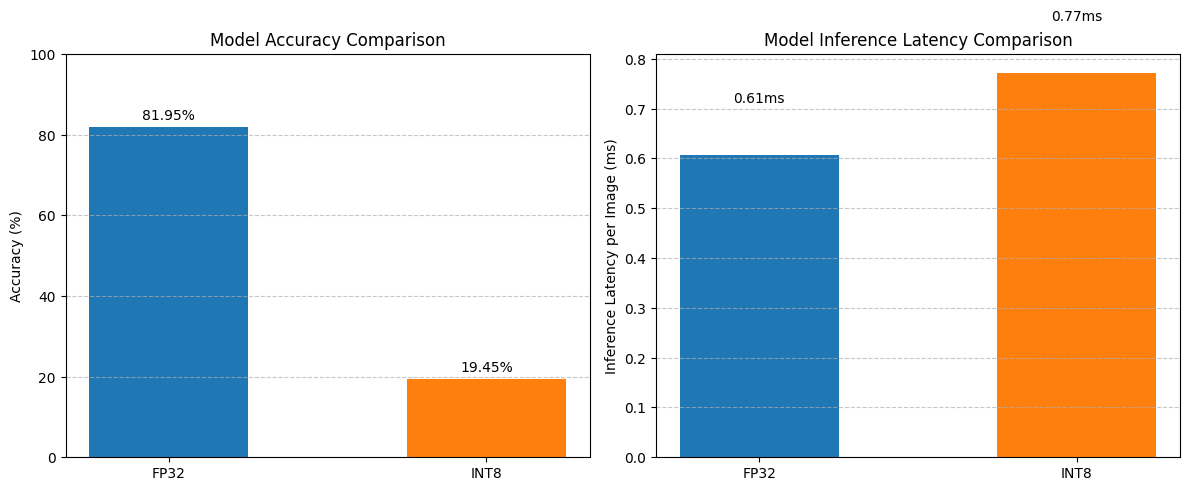

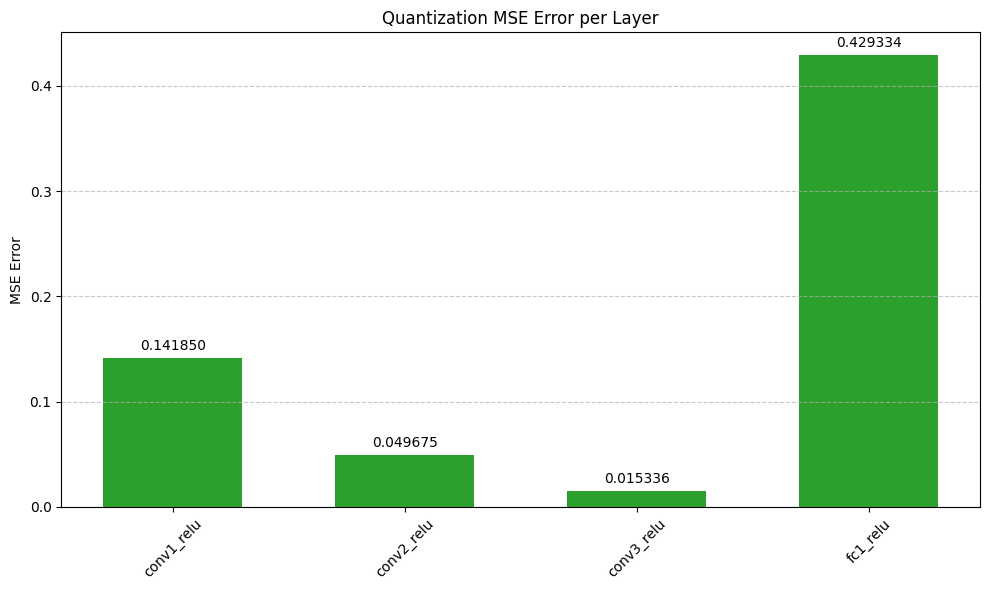

In [35]:
print("\n" + "="*50)
print("生成可视化结果...")

# 精度对比图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
models = ['FP32', 'INT8']
accuracies = [fp32_accuracy, int8_accuracy]
bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e'], width=0.5)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.2f}%', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 推理延迟对比图
plt.subplot(1, 2, 2)
latencies = [fp32_latency, int8_latency]
bars = plt.bar(models, latencies, color=['#1f77b4', '#ff7f0e'], width=0.5)
plt.ylabel('Inference Latency per Image (ms)')
plt.title('Model Inference Latency Comparison')
for bar, lat in zip(bars, latencies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{lat:.2f}ms', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("quantization_comparison.png", dpi=300)
plt.show()

# 各层量化MSE误差图
plt.figure(figsize=(10, 6))
layers = list(mse_errors.keys())
errors = list(mse_errors.values())
plt.bar(layers, errors, color='#2ca02c', width=0.6)
plt.ylabel('MSE Error')
plt.title('Quantization MSE Error per Layer')
plt.xticks(rotation=45)
for i, err in enumerate(errors):
    plt.text(i, err + max(errors)*0.01, f'{err:.6f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("layer_mse_errors.png", dpi=300)
plt.show()